<a href="https://colab.research.google.com/github/1-brain-cell/python-dga/blob/master/day_4/morning_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DGA306 Day 4 Workshop Materials: Machine Learning for Data Analysis (Morning)

Lead Instructor: <code>Sirasit Lochanachit</code>

# Linear Regression

## เป้าหมาย
เมื่อจบ session นี้ ผู้เรียนจะสามารถ:
- **อธิบาย** หลักการของ Regression และความแตกต่างจาก analytics ประเภทอื่น
- **สร้าง** โมเดล Linear Regression อย่างง่ายและแบบหลายตัวแปร
- **แปลผล** ค่าสัมประสิทธิ์ (coefficients) และตัวชี้วัดความแม่น (metrics) เพื่อนำไปใช้ตัดสินใจ

## Regression อยู่ส่วนไหนใน Data Analytics?

เราสามารถแบ่งการวิเคราะห์ข้อมูลออกเป็น 4 ระดับ:

| ระดับ | ภาษาอังกฤษ | คำถามที่ตอบ | ตัวอย่าง |
|-------|------------|------------|---------|
| 1 | Descriptive | เกิดอะไรขึ้น? | สถิติประชากรรายแขวง |
| 2 | Diagnostic | ทำไมถึงเกิด? | ทำไมแขวงนี้ประชากรหนาแน่น? |
| **3** | **Predictive** | **จะเกิดอะไรต่อไป?** | **ทำนายประชากรจากจำนวนบ้าน** |
| 4 | Prescriptive | ควรทำอะไร? | วางแผนสาธารณูปโภคล่วงหน้า |

**Linear Regression** อยู่ในกลุ่ม **Predictive Analytics** และเป็น **Supervised Learning** ประเภทหนึ่ง

> Regression ทำนาย **ตัวเลขต่อเนื่อง** (เช่น จำนวนประชากร, อุณหภูมิ, เงินเดือน)

## Feature, Target

ก่อนสร้างโมเดล เราต้องเข้าใจคำศัพท์หลัก 2 คำ:

- **Feature (X)** = ตัวแปรต้น หรือ input
- **Target (y)** = ตัวแปรตาม หรือ output คือ สิ่งที่เราต้องการ "ทำนาย"

## ชุดข้อมูล: ประชากรรายแขวง กรุงเทพมหานคร

original data [here](https://data.go.th/dataset/bmastats)

ในที่นี้ เรามีการประยุกต์ใช้ข้อมูลที่เตรียมจากข้อมูลเดิม โดยคัดเหลือ 4 คอลัมน์ ดังต่อไปนี้

| Column | ความหมาย | ประเภท |
|--------|---------|--------|
| `d_name` | ชื่อแขวง | ข้อความ |
| `pop_total` | จำนวนประชากรรวม (คน) | ตัวเลข : **TARGET** |
| `area_km2` | พื้นที่แขวง (ตร.กม.) | ตัวเลข : Feature |
| `house_amt` | จำนวนหลังคาเรือน | ตัวเลข : Feature หลัก |

**โจทย์:** ใช้ `house_amt` (จำนวนบ้าน) ทำนาย `pop_total` (ประชากร) รายแขวง
จำนวนข้อมูล: **163 แถว** (163 แขวงของ กทม.)

## Import Library and Load Data

In [ ]:
!pip install -U scikit-learn


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# นำเข้า library ที่จำเป็น และโหลดข้อมูล
import pandas as pd

# โหลดไฟล์ข้อมูลประชากรรายแขวง กทม.
bma = pd.read_csv("bma.csv", encoding="utf-8-sig")

In [ ]:
# ดูข้อมูล 5 แถวแรก
bma.head()

,d_name,pop_total,area_km2,house_amt
0,แขวงห้วยขวาง,25879.0,5.34,30337.0
1,แขวงสามเสนนอก,38204.0,4.28,23822.0
2,แขวงบางกะปิ,17606.0,5.41,25609.0
3,แขวงทุ่งสองห้อง,76457.0,16.89,39222.0
4,แขวงตลาดบางเขน,28120.0,5.96,16580.0


In [ ]:
# ตรวจขนาดข้อมูล: (จำนวนแถว, จำนวนคอลัมน์)
bma.shape

(163, 4)

## สำรวจข้อมูลเบื้องต้น

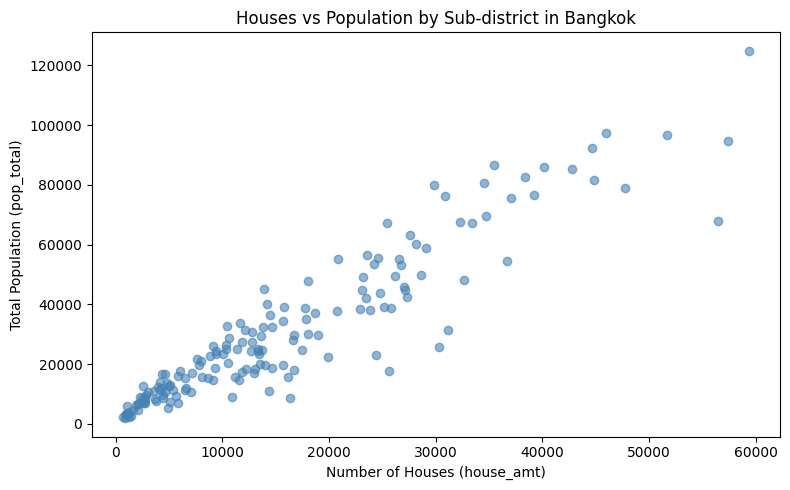

In [ ]:
# แสดง scatter plot ความสัมพันธ์ระหว่างจำนวนบ้าน และประชากร
import matplotlib.pyplot as plt

# วาด scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(bma['house_amt'], bma['pop_total'], alpha=0.6, color='steelblue')
plt.xlabel("Number of Houses (house_amt)")
plt.ylabel("Total Population (pop_total)")
plt.title("Houses vs Population by Sub-district in Bangkok")
plt.tight_layout()
plt.show()

### สังเกตจาก Scatter Plot

จากกราฟจะเห็นแนวโน้มว่า แขวงที่มีบ้านมาก จะมีประชากรมาก

ข้อสรุป: **`house_amt` เหมาะนำมาใช้ทำนาย `pop_total`**

In [ ]:
# ดูสถิติเบื้องต้นของ 3 คอลัมน์ตัวเลขหลัก
bma[['pop_total', 'area_km2', 'house_amt']].describe()

,pop_total,area_km2,house_amt
count,163.000000,163.000000,163.000000
mean,31019.380368,8.833742,15983.907975
std,25047.174745,11.185475,13090.634939
min,1906.000000,0.140000,703.000000
25%,11612.500000,1.445000,5044.500000
50%,23520.000000,4.890000,12980.000000
75%,43112.500000,12.605000,24342.000000
max,124916.000000,84.710000,59364.000000


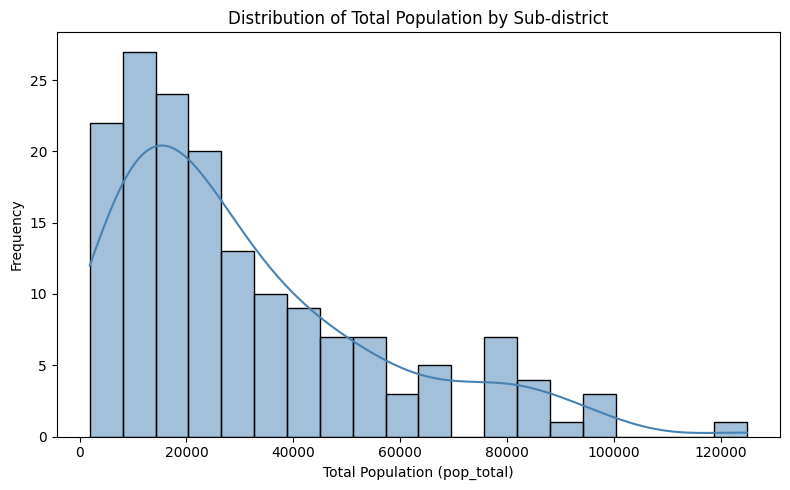

In [ ]:
# ดู distribution ของ target (pop_total) ด้วย histogram
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(data=bma, x='pop_total', bins=20, kde=True, color='steelblue')
plt.xlabel("Total Population (pop_total)")
plt.ylabel("Frequency")
plt.title("Distribution of Total Population by Sub-district")
plt.tight_layout()
plt.show()

### Correlation (ค่าสหสัมพันธ์)

Correlation คือ ค่าที่บอกว่า **"สิ่ง 2 สิ่ง มีความสัมพันธ์แปรผันตามกัน หรือ สวนทางกัน มากน้อยแค่ไหน"** มีค่าตั้งแต่ **-1 ถึง 1**

| ค่า Correlation | รูปแบบความสัมพันธ์ | ความหมายและทิศทาง | ตัวอย่างจริง |
| :---: | :--- | :--- | :--- |
| **`+1`** | เชิงบวกสมบูรณ์ | **ไปด้วยกัน 100%**<br>สิ่งหนึ่งเพิ่ม อีกสิ่งเพิ่มตาม | ขับรถระยะทางไกลขึ้น $\rightarrow$ ค่าน้ำมันที่ต้องจ่ายเพิ่มขึ้น |
| **0.x** | เชิงบวก | **มีแนวโน้มไปทางเดียวกัน**<br>สิ่งหนึ่งเพิ่ม อีกสิ่งมักจะเพิ่มตาม | `house_amt` เพิ่ม $\rightarrow$ `pop_total` เพิ่มตาม |
| **`0`** | ไม่มีความสัมพันธ์ | **ไม่เกี่ยวข้องกัน** | ขนาดรองเท้า $\rightarrow$ คะแนนสอบวิชาเลข |
| **-0.x** | เชิงลบ | **มีแนวโน้มสวนทางกัน**<br>สิ่งหนึ่งเพิ่ม อีกสิ่งมักจะลดลง | ราคาตั๋วเครื่องบินแพงขึ้น $\rightarrow$ จำนวนคนซื้อมักจะลดลง |
| **`-1`** | เชิงลบสมบูรณ์ | **สวนทางกัน 100%**<br>สิ่งหนึ่งเพิ่ม อีกสิ่งลดลง | ระยะทางที่เหลือถึงเป้าหมาย $\rightarrow$ ลดลงเมื่อเวลาผ่านไป |

In [ ]:
# ดูค่า Correlation ระหว่าง features กับ target
bma[['house_amt', 'area_km2', 'pop_total']].corr()

,house_amt,area_km2,pop_total
house_amt,1.000000,0.380809,0.930707
area_km2,0.380809,1.000000,0.474978
pop_total,0.930707,0.474978,1.000000


### สมมติฐานเพิ่มเติมจากการสำรวจข้อมูล

จากตาราง Correlation (ค่าสหสัมพันธ์)เราอาจตั้งสมมติฐานว่า:
- **`house_amt` vs `pop_total`**: ค่าที่ได้สูง => ความสัมพันธ์เชิงเส้นค่อนข้างชัดเจน => เหมาะเป็น feature หลัก
- **`area_km2` vs `pop_total`**: ค่าต่ำกว่า => เป็นไปได้ว่า แขวงพื้นที่เล็กแต่อาจจะมีจำนวนคนหนาแน่น, ในขณะที่แขวงที่มีพื้นที่ใหญ่อาจมีจำนวนคนเบาบาง ก็ได้ (แต่ค่า correlation ไม่ใช่ค่าลบ หมายความว่าโดยภาพรวมแล้ว ขนาดพื้นที่ยังคงแปรผันตามจำนวนคนอยู่ ยังไม่ได้เป็นความสัมพันธ์แบบแปรผกผันกัน)

---
## Simple Linear Regression

### กำหนด Feature และ Target

ใช้ `house_amt` ทำนาย `pop_total`

เราจะสร้างโมเดลเส้นตรงอย่างง่ายโดยใช้ **feature เดียว** คือ `house_amt`

**สิ่งที่ต้องเตรียม:**
- **X** = Feature matrix (ต้องเป็น 2D / DataFrame) => ใช้ `bma[['house_amt']]` (bracket คู่)
- **y** = Target vector (1D / Series) => ใช้ `bma['pop_total']` (bracket เดี่ยว)

In [ ]:
# สร้าง X (Feature matrix) ใช้ bracket คู่เพื่อให้ได้ DataFrame 2D
X = bma[['house_amt']]

In [ ]:
# ตรวจ X ควรเห็น 1 column
X.head()

,house_amt
0,30337.0
1,23822.0
2,25609.0
3,39222.0
4,16580.0


In [ ]:
type(X)

pandas.core.frame.DataFrame

In [ ]:
# สร้าง y (Target series) และตรวจสอบ
y = bma['pop_total']
y.head()

0    25879.0
1    38204.0
2    17606.0
3    76457.0
4    28120.0
Name: pop_total, dtype: float64

In [ ]:
type(y)

pandas.core.series.Series

### แบ่งข้อมูลเป็น Train และ Test

ก่อนเทรนโมเดล เราแบ่งข้อมูล 163 แถวออกเป็น 2 ส่วน:

- **Train set (80%)** : ใช้สอนโมเดล
- **Test set (20%)** : ใช้วัดความแม่นกับข้อมูลที่โมเดลไม่เคยเห็น

พารามิเตอร์สำคัญ:
- `test_size=0.2` = แบ่ง 20% เป็น test
- `random_state=42` = กำหนดค่า seed ให้สุ่มซ้ำได้เหมือนเดิมทุกครั้ง (ไม่ใช่ค่าพิเศษ ใช้เลขอื่นก็ได้)

In [ ]:
# import และแบ่งข้อมูล train/test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# ตรวจขนาด train set
X_train.shape

(130, 1)

In [ ]:
# ตรวจขนาด test set
X_test.shape

(33, 1)

### สร้างและเทรนโมเดล Linear Regression

ขั้นตอนการสร้างโมเดลด้วย sklearn มี 2 ขั้น:

1. **สร้างโมเดลเปล่า** (object ว่าง ยังไม่รู้อะไร)
2. **fit()** สอนโมเดลด้วย train data => โมเดลจะหา intercept_ และ coef_ ที่ดีที่สุด

In [ ]:
# import และสร้าง LinearRegression object
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

In [ ]:
# เทรนโมเดล — สอนให้โมเดลเรียนรู้จาก train data
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
# ดูค่า intercept (β0) : ค่าคงที่เมื่อ house_amt = 0
lr.intercept_

2716.43424035122

In [ ]:
# ดูค่า coefficient (β1) : slope ของ house_amt
lr.coef_

array([1.75415342])

### แปลผล Coefficient และ Intercept

**Coefficient (β1):**
ค่า coef ที่ได้ ≈ จำนวนประชากรที่เพิ่มขึ้นเฉลี่ย **ต่อการเพิ่มขึ้น 1 หลังคาเรือน**
(เมื่อปัจจัยอื่นคงที่)

**Intercept (β0):**
คือค่าทำนาย pop_total เมื่อ house_amt = 0

### การทำนายด้วยโมเดลที่เทรนแล้ว

เมื่อโมเดลเรียนรู้เสร็จแล้ว ใช้ `.predict()` กับ `X_test`
โมเดลจะคืน array ของค่าทำนาย (`y_pred`) สำหรับแต่ละแถวใน test set

In [ ]:
# ทำนายค่า pop_total สำหรับ test set
y_pred = lr.predict(X_test)
y_pred

array([ 7159.70486471, 17823.20353248,  6986.04367568, 39122.13441323,
       35550.67804087, 14288.58438203, 11576.6631877 ,  9080.50286458,
       26506.26298395, 50648.67656588, 33914.05289578, 15018.31220664,
       42828.66059928,  4805.63096898, 37659.17045717, 26051.93724699,
        7050.94735239, 10497.85883161, 18656.42640914, 63243.49815407,
       52899.25540956, 21115.74951034, 30430.30419464, 13339.58737936,
       81035.87633917, 10860.96859049, 53746.51151361,  3949.6040978 ,
       39192.30055021, 28360.40315369, 70023.30113991, 15281.43522032,
        4442.5212101 ])

In [ ]:
# เทียบค่าจริง (Actual) กับค่าทำนาย (Predicted)
cdf = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
cdf.head(10)

,Actual,Predicted
135,12583.0,7159.704865
115,15239.0,17823.203532
131,7422.0,6986.043676
55,37905.0,39122.134413
95,37065.0,35550.678041
29,11999.0,14288.584382
156,13027.0,11576.663188
51,11093.0,9080.502865
101,20166.0,26506.262984
145,42560.0,50648.676566


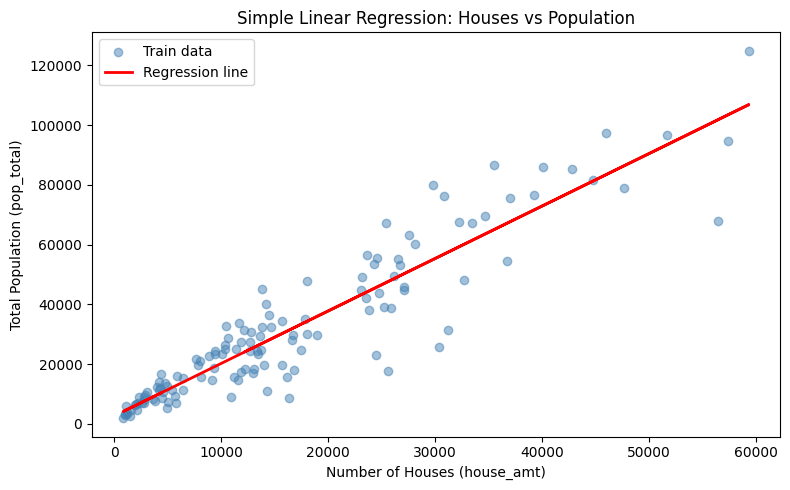

In [ ]:
# แสดงเส้น regression บน scatter ของ train data
plt.figure(figsize=(8, 5))

# จุด train data
plt.scatter(X_train['house_amt'], y_train, alpha=0.5, color='steelblue', label='Train data')

# เส้น regression (ทำนายบน X_train)
plt.plot(X_train['house_amt'], lr.predict(X_train), color='red', linewidth=2, label='Regression line')

plt.xlabel("Number of Houses (house_amt)")
plt.ylabel("Total Population (pop_total)")
plt.title("Simple Linear Regression: Houses vs Population")
plt.legend()
plt.tight_layout()
plt.show()

### เทียบเส้น regression บน Train vs Test

วาด 2 กราฟข้างกัน เพื่อดูว่าเส้น regression ที่เรียนจาก train set ใช้กับ **test set (ข้อมูลที่โมเดลไม่เคยเห็น)** ได้ดีแค่ไหน
- ซ้าย: Train set
- ขวา: Test set => เส้น regression เส้นเดียวกัน แต่จุดเป็นข้อมูลใหม่

> 💡 ถ้าเส้นยังพอดีกับจุดบน test set แสดงว่าโมเดล **generalize** ได้ดี ไม่ใช่แค่จำ train data

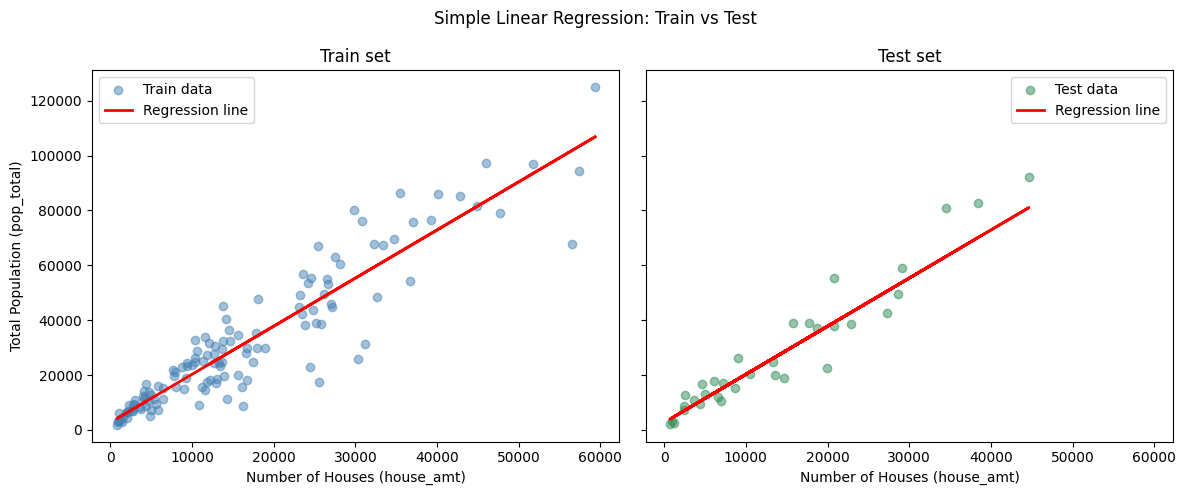

In [ ]:
# เทียบ Train vs Test เคียงข้างกัน (ใช้แกน x, y เดียวกันเพื่อเทียบง่าย)
fig, ax = plt.subplots(ncols=2, figsize=(12, 5), sharex=True, sharey=True)

# ซ้าย: Train set
ax[0].scatter(X_train['house_amt'], y_train, alpha=0.5, color='steelblue', label='Train data')
ax[0].plot(X_train['house_amt'], lr.predict(X_train), color='red', linewidth=2, label='Regression line')
ax[0].set_xlabel("Number of Houses (house_amt)")
ax[0].set_ylabel("Total Population (pop_total)")
ax[0].set_title("Train set")
ax[0].legend()

# ขวา: Test set (จุดเป็นข้อมูลที่โมเดลไม่เคยเห็น แต่ใช้เส้น regression เส้นเดียวกัน)
ax[1].scatter(X_test['house_amt'], y_test, alpha=0.5, color='seagreen', label='Test data')
ax[1].plot(X_test['house_amt'], y_pred, color='red', linewidth=2, label='Regression line')
ax[1].set_xlabel("Number of Houses (house_amt)")
ax[1].set_title("Test set")
ax[1].legend()

fig.suptitle("Simple Linear Regression: Train vs Test")
plt.tight_layout()
plt.show()

### แบบฝึกหัด: ทำนาย pop_total จาก house_amt ใหม่

**โจทย์:** สมมติมีแขวงหนึ่งที่มีจำนวนบ้าน `house_amt = 20000` หลัง

ให้ทำนายว่าแขวงนั้นควรมีประชากรประมาณกี่คน

**Hint:**
1. สร้าง DataFrame ใหม่ที่มี column `house_amt` และค่า 20000
2. เรียก `lr.predict(...)` กับ DataFrame นั้น

> เพิ่มเติม input ต้องเป็น DataFrame 2D (ใช้ bracket คู่) เหมือนตอนเทรน

In [ ]:
# เฉลย
# สร้าง DataFrame ใหม่สำหรับแขวงสมมติที่มี house_amt = 20000
new_data_b = pd.DataFrame({'house_amt': [20000]})

# ทำนาย pop_total ด้วยโมเดล simple regression
result_b = lr.predict(new_data_b)

# แสดงผลลัพธ์
print(f"ทำนายประชากรของแขวงที่มีบ้าน 20,000 หลัง: {result_b[0]:,.0f} คน")

ทำนายประชากรของแขวงที่มีบ้าน 20,000 หลัง: 37,800 คน


---
## Multiple Linear Regression

เราพิสูจน์แล้วว่า `house_amt` เป็น feature ที่ดี
ต่อไปลองเพิ่ม `area_km2` เข้าไปด้วย เพื่อดูว่าโมเดลจะแม่นขึ้นหรือไม่

(เสริม) สมการ Multiple Linear Regression:
$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2$$
- $x_1$ = `house_amt`
- $x_2$ = `area_km2`

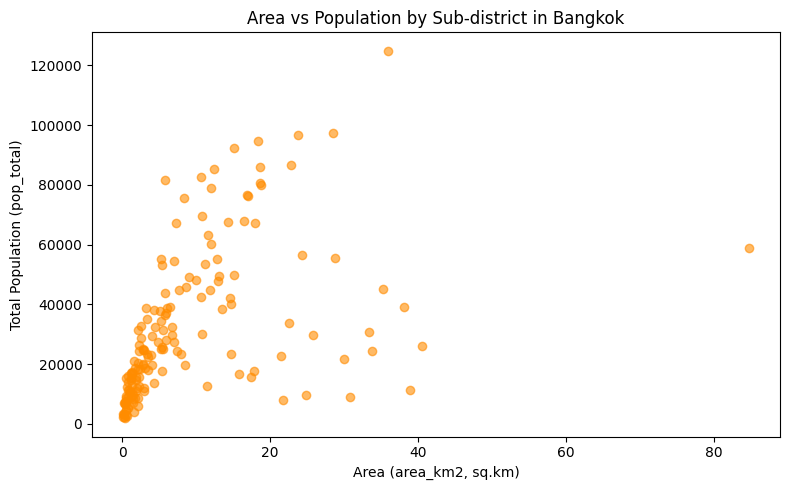

In [ ]:
# ดู scatter ของ area_km2 vs pop_total เพื่อเปรียบเทียบกับ house_amt
plt.figure(figsize=(8, 5))
plt.scatter(bma['area_km2'], bma['pop_total'], alpha=0.6, color='darkorange')
plt.xlabel("Area (area_km2, sq.km)")
plt.ylabel("Total Population (pop_total)")
plt.title("Area vs Population by Sub-district in Bangkok")
plt.tight_layout()
plt.show()

### พิจารณาจาก Scatter Plot

จาก scatter plot จะเห็นว่า `area_km2` กระจายมากกว่า `house_amt` อย่างชัดเจน

อาจตีความได้ว่า ใน กทม.:
- **แขวงชั้นใน** (เช่น สัมพันธวงศ์, บางรัก): พื้นที่เล็ก แต่ประชากรหนาแน่นมาก
- **แขวงชานเมือง** (เช่น หนองจอก, ลาดกระบัง): พื้นที่ใหญ่มาก แต่ประชากรน้อยกว่า

มีแนวโน้มว่าถ้าใช้ขนาดพื้นที่อย่างเดียวอาจทำนายประชากรได้ไม่ดี แต่เมื่อ **ใช้ร่วมกับ `house_amt`** **อาจจะ**ช่วยในการทำนายของโมเดลก็ได้

### Feature ที่ "ไม่ควร" ใช้

บาง column อาจดูน่าสนใจแต่ **ห้ามนำมาเป็น feature** เด็ดขาด:

- **`pop_density`** (ความหนาแน่นประชากร) = คำนวณจาก `pop_total / area_km2`
  => ใช้ target คำนวณ => โมเดลจะ "ลอกคำตอบ" ไม่ใช่เรียนรู้จากข้อมูลจริง ๆ
- **`pop_male` / `pop_female`** => เมื่อรวมกันได้ `pop_total` พอดี

สิ่งนี้เรียกว่า **Data Leakage** : โมเดลจะดูดีเกินจริงในการทดสอบ แต่ใช้จริงไม่ได้

ชุดข้อมูล `bma.csv` ที่เตรียมไว้สำหรับงานนี้ได้ตัด column เหล่านี้ออกแล้ว

In [ ]:
# สร้าง X_multi — feature matrix ที่มี 2 ตัวแปร
X_multi = bma[['house_amt', 'area_km2']]
X_multi.head()

,house_amt,area_km2
0,30337.0,5.34
1,23822.0,4.28
2,25609.0,5.41
3,39222.0,16.89
4,16580.0,5.96


In [ ]:
# แบ่ง train/test ด้วย random_state เดิม เพื่อให้เทียบกับ simple model ได้ยุติธรรม
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

In [ ]:
# เทรนโมเดล Multiple Regression
lr_multi = LinearRegression()
lr_multi.fit(X_train_m, y_train_m)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
# ดู coefficients ของโมเดลหลายตัวแปร — จะได้ค่า 2 ตัว
lr_multi.coef_

array([  1.61792124, 470.02035609])

### แปลผล Coefficient ใน Multiple Regression

- **coef[0]** (ของ `house_amt`): ถ้า house_amt เพิ่ม 1 หลัง โดยที่ area_km2 คงที่ => แล้ว pop_total เปลี่ยนไปกี่คน
- **coef[1]** (ของ `area_km2`): ถ้า area_km2 เพิ่ม 1 ตร.กม. โดยที่ house_amt คงที่ => แล้ว pop_total เปลี่ยนไปกี่คน

In [ ]:
# ทำนายบน test set ด้วยโมเดลหลายตัวแปร
y_pred_m = lr_multi.predict(X_test_m)

### แบบฝึกหัดเพิ่มเติม: ทำนายด้วย Multiple Regression

**โจทย์:** สมมติมีแขวงหนึ่งที่มี:
- `house_amt` = 25,000 หลัง
- `area_km2` = 10 ตร.กม.

ให้ทำนายว่าแขวงนั้นควรมีประชากรประมาณกี่คน และลองตีความว่าตัวเลขที่ได้ **สมเหตุสมผลหรือไม่**

In [ ]:
# เฉลย
# สร้าง DataFrame ใหม่ — column ต้องเรียงเหมือน X_multi (house_amt ก่อน area_km2)
new_data_c = pd.DataFrame({'house_amt': [25000], 'area_km2': [10]})

# ทำนาย pop_total ด้วยโมเดล multiple regression
result_c = lr_multi.predict(new_data_c)

# แสดงผลลัพธ์และตีความ
print(f"ทำนายประชากรของแขวงสมมติ: {result_c[0]:,.0f} คน")
# ตีความ: ค่าที่ได้สมเหตุสมผลเมื่อเทียบกับขนาดบ้าน 25,000 หลัง
# แขวงขนาดกลาง-ใหญ่ใน กทม. มักมีประชากรในช่วงหลักหมื่นถึงแสน

ทำนายประชากรของแขวงสมมติ: 46,103 คน


## Evaluation Metrics

เราจะใช้ 4 ตัวชี้วัดหลักเพื่อประเมินโมเดล:

| Metric | ภาษาไทย | หน่วย | ตีความ |
|--------|---------|-------|--------|
| **R²** (R-squared) | ค่าอธิบายความแปรปรวน | 0–1 | ยิ่งใกล้ 1 ยิ่งดี |
| **MAE** | Mean Absolute Error | เดียวกับ target (คน) | ค่าเฉลี่ยที่ผิดพลาดในแต่ละจุด |
| **MSE** | Mean Squared Error | กำลังสองของ target | ให้น้ำหนักกับ error ที่ใหญ่มาก |
| **RMSE** | Root Mean Squared Error | เดียวกับ target (คน) | MSE ถอดรากมาให้อ่านง่ายขึ้น |

ซึ่งการจะวัดสิ่งเหล่านี้ เกิดจากการเทียบกันระหว่างผลเฉลย และค่าที่โมเดลทำนายจากชุดข้อมูลที่ใช้ test

> 💡 ในส่วนของ MSE ตัวอย่าง เช่น หน่วยเป็น "คน²" จะทำให้ตีความยาก จึงนิยมใช้ **RMSE** ซึ่งมีหน่วยเดียวกับ target มากกว่า

In [ ]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error
)

r2_simple = r2_score(y_test, y_pred)
mae_simple = mean_absolute_error(y_test, y_pred)

mse_simple = mean_squared_error(y_test, y_pred)
rmse_simple = root_mean_squared_error(y_test, y_pred)

print("Simple Regression Metrics:")
print(f"  R²   = {r2_simple:.4f}")
print(f"  MAE  = {mae_simple:,.0f} คน")
print(f"  MSE  = {mse_simple:,.0f}")
print(f"  RMSE = {rmse_simple:,.0f} คน")

Simple Regression Metrics:
  R²   = 0.9090
  MAE  = 5,258 คน
  MSE  = 49,420,755
  RMSE = 7,030 คน


In [ ]:
# คำนวณ metrics ของโมเดล Multiple Regression
r2_multi = r2_score(y_test_m, y_pred_m)
mae_multi = mean_absolute_error(y_test_m, y_pred_m)
mse_multi = mean_squared_error(y_test_m, y_pred_m)
rmse_multi = root_mean_squared_error(y_test_m, y_pred_m)

print("Multiple Regression Metrics:")
print(f"  R²   = {r2_multi:.2f}")
print(f"  MAE  = {mae_multi:,.2f} คน")
print(f"  MSE  = {mse_multi:,.2f}")
print(f"  RMSE = {rmse_multi:,.2f} คน")

Multiple Regression Metrics:
  R²   = 0.8686
  MAE  = 5,654 คน
  MSE  = 71,326,051
  RMSE = 8,445 คน


In [ ]:
# สร้างตารางเปรียบเทียบ simple vs multiple
comparison_data = {
    'Metric': ['R²', 'MAE (คน)', 'MSE', 'RMSE (คน)'],
    'Simple (house_amt)': [
        round(r2_simple, 2),
        round(mae_simple, 2),
        round(mse_simple, 2),
        round(rmse_simple, 2)
    ],
    'Multiple (house_amt + area_km2)': [
        round(r2_multi, 2),
        round(mae_multi, 2),
        round(mse_multi, 2),
        round(rmse_multi, 2)
    ]
}
comparison_df = pd.DataFrame(comparison_data)
comparison_df

,Metric,Simple (house_amt),Multiple (house_amt + area_km2)
0,R²,0.91,0.87
1,MAE (คน),5257.79,5654.09
2,MSE,49420754.83,71326050.66
3,RMSE (คน),7029.99,8445.48


**สังเกตได้ว่า**
> การเพิ่ม feature ไม่ได้ทำให้โมเดลดีขึ้นเสมอไป

การเลือก feature อย่างรอบคอบ (Feature Selection) จึงเป็นสิ่งที่สำคัญในการทำ Machine Learning

---
# BONUS

> ⏱️ **ส่วนนี้เป็นแบบฝึกเสริม**

## (Bonus) — สถิติการเกษตรรายปี

### แนะนำชุดข้อมูลใหม่: มูลค่าผลผลิตสินค้าภาคการเกษตรที่สำคัญ พืชผลทางการเกษตร
องค์กร : สำนักงานจังหวัดสระบุรี

original data [here](https://data.go.th/dataset/dataset_10_19_11)

ชุดข้อมูลที่สอง `agri.csv` ทำการเตรียมมาจากข้อมูลเดิม ซึ่งรวบรวมไว้ 6 ปี (~48 แถว)

| Column | ความหมาย |
|--------|---------|
| `ปี` | ปีของข้อมูล |
| `พื้นที่ (ไร่)` | พื้นที่เพาะปลูก (ไร่) |
| `ผลผลิตรวม (ตัน)` | ผลผลิตทั้งหมด (ตัน) — **TARGET** |
| `มูลค่า (บาท)` | มูลค่าผลผลิต (บาท) |
| `ครัวเรือนเกษตรกร` | จำนวนครัวเรือนเกษตรกร |
| `ผลผลิตเฉลี่ย (กก./ไร่)` | ผลผลิตเฉลี่ยต่อพื้นที่ |

**โจทย์:** ทำนาย `ผลผลิตรวม (ตัน)` จาก `พื้นที่ (ไร่)`

> ⚠️ **ข้อควรระวัง:** ตัวเลขในชุดนี้เก็บเป็น **string ที่มี comma** (เช่น "1,234,567")
> ต้องแปลงให้เป็นตัวเลขก่อน

In [ ]:
# โหลดข้อมูลเกษตร และดู 5 แถวแรก
agri = pd.read_csv("agri.csv", encoding="utf-8-sig")
agri.head()

,ชนิดพืช,ข้อมูล (ปี),ครัวเรือนเกษตรกร,พื้นที่ (ไร่),ผลผลิตเฉลี่ย (กก./ไร่),ผลผลิตรวม (ตัน),ราคาผลผลิต (บาท./กก.),มูลค่า (บาท)
0,ข้าวนาปี,2563,"13,886","308,498",616,"190,035",9.10,"1,729,316,389"
1,ข้าวนาปี,2564,"15,249","312,591",719,"224,744",7.35,"1,651,868,921"
2,ข้าวนาปี,2565,"14,149","315,908",678,"214,186",9.20,"1,970,507,741"
3,ข้าวนาปี,2566,"15,151","312,771",729,"228,010",8.87,"2,022,449,223"
4,ข้าวนาปี,2567,"15,211","317,241",773,"245,227",8.73,"2,140,834,267"


## แบบฝึก 1 : เลือก Feature ที่ถูกต้อง

ลองพิจารณาว่า column ไหน **ใช้เป็น feature ได้** และ column ไหน **ใช้ไม่ได้**

คำถาม:
1. `พื้นที่ (ไร่)` — ใช้เป็น feature ได้หรือไม่? เพราะอะไร?
2. `ครัวเรือนเกษตรกร` — ใช้ได้หรือไม่? มีความสัมพันธ์กับ target อย่างไร?
3. `มูลค่า (บาท)` — ใช้ได้หรือไม่? ลองคิดว่ามันสัมพันธ์กับ target แบบไหน?
4. `ผลผลิตเฉลี่ย (กก./ไร่)` — ใช้ได้หรือไม่?

## แบบฝึก 2 : หา Data Leakage ในชุดข้อมูลเกษตร

ลองตรวจสอบความสัมพันธ์เหล่านี้:

- **มูลค่า = ผลผลิตรวม × ราคา**
  > `มูลค่า (บาท)` คำนวณมาจาก target โดยตรง => นี่คือ **Leakage**

- **ผลผลิตรวม ≈ พื้นที่ × ผลผลิตเฉลี่ยต่อไร่**
  > `ผลผลิตเฉลี่ย (กก./ไร่)` เป็นส่วนหนึ่งของสูตรคำนวณ target => **Leakage**

**คำถาม:** ถ้าเราใช้ `มูลค่า` หรือ `ผลผลิตเฉลี่ย` เป็น feature
โมเดลจะ "ดูดี" หรือไม่? และทำไมถึงใช้จริงไม่ได้?

> 💡 ถ้า feature เป็น **สูตรของ target** โมเดลจะ "ลอกคำตอบ" แทนที่จะเรียนรู้ความสัมพันธ์จริง

## แบบฝึก 3 : ทำไมถึงห้ามใช้ปี (Year) เป็น Feature?

ชุดข้อมูลนี้รวบรวม 6 ปี ; ดูเหมือนเพิ่มจุดข้อมูลขึ้น
แต่จริง ๆ แล้วเราแค่เพิ่มจุดบนความสัมพันธ์ **พื้นที่ → ผลผลิต** ที่มีอยู่แล้ว

ถ้าใช้ `ปี` เป็น feature:
- โมเดลจะเรียนรู้ว่าผลผลิตเปลี่ยนแปลงตามเวลา
- นี่กลายเป็น **Time Series Prediction** ซึ่งเป็น technique คนละแบบ (นอกขอบเขตของวันนี้)

**ข้อสรุป:** ใช้ได้เฉพาะ `พื้นที่ (ไร่)` => `ผลผลิตรวม (ตัน)` สำหรับ exercise นี้

In [ ]:
# แบบฝึกหัด: สร้างโมเดล Linear Regression พื้นที่ to ผลผลิตรวม
#
# แนวทาง:
# 1. แปลง column ที่ต้องใช้จาก string เป็นตัวเลขด้วย named function:
#    def to_number(s): return float(str(s).replace(",", ""))
#    agri["พื้นที่ (ไร่)"] = agri["พื้นที่ (ไร่)"].map(to_number)
#    agri["ผลผลิตรวม (ตัน)"] = agri["ผลผลิตรวม (ตัน)"].map(to_number)
# 2. กำหนด X = agri[['พื้นที่ (ไร่)']], y = agri['ผลผลิตรวม (ตัน)']
# 3. train_test_split, fit, predict
# 4. คำนวณ R², RMSE — ค่าจะเสถียรน้อยกว่า primary เพราะมีข้อมูลน้อยกว่า (~48 แถว)
# 5. ลองเปลี่ยน random_state หลาย ๆ ค่า จะเห็นว่าผลเปลี่ยนไปมากกว่า primary

# เฉลย
# ขั้นที่ 1: แปลง string-with-comma เป็นตัวเลขด้วย named function
def to_number(s):
    return float(str(s).replace(",", ""))

agri["พื้นที่ (ไร่)"] = agri["พื้นที่ (ไร่)"].map(to_number)
agri["ผลผลิตรวม (ตัน)"] = agri["ผลผลิตรวม (ตัน)"].map(to_number)

# ขั้นที่ 2: กำหนด X และ y
X_agri = agri[['พื้นที่ (ไร่)']]
y_agri = agri['ผลผลิตรวม (ตัน)']

# ขั้นที่ 3: แบ่ง train/test
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_agri, y_agri, test_size=0.2, random_state=42
)

# ขั้นที่ 4: เทรนโมเดลและทำนาย
lr_agri = LinearRegression()
lr_agri.fit(X_train_a, y_train_a)
y_pred_a = lr_agri.predict(X_test_a)

# ขั้นที่ 5: แสดง metrics
print(f"R²   = {r2_score(y_test_a, y_pred_a):.4f}")
print(f"RMSE = {root_mean_squared_error(y_test_a, y_pred_a):,.0f} ตัน")

R²   = 0.6401
RMSE = 56,893 ตัน
